# Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Reading File

In [2]:
sales = pd.read_csv("../data/raw/rawretaildata.csv")
# pd.reset_option('display.max_colwidth')
# pd.reset_option('display.width')
# pd.reset_option('display.max_rows')

# Data Description

In [3]:
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])
sales.rename(columns= {"Customer ID" : "CustID"}, inplace= True)
print(sales.head())
print(sales.info())
print(sales.describe())
print("Min Value: ", sales["InvoiceDate"].min())
print("Max Value: ", sales["InvoiceDate"].max())
print("Total Sales Earning: $" , sales["Price"].sum())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price   CustID         Country  
0 2009-12-01 07:45:00   6.95  13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75  13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75  13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10  13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25  13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1048575 non

# Countries

In [4]:
countries = sales["Country"].unique()
print(countries)
Country = sales["Country"].nunique()
print("Total Countries:", Country)

['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Japan' 'Denmark' 'Nigeria' 'Netherlands' 'Poland' 'Spain'
 'Channel Islands' 'Italy' 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden'
 'United Arab Emirates' 'Finland' 'Switzerland' 'Unspecified' 'Malta'
 'Bahrain' 'RSA' 'Bermuda' 'Hong Kong' 'Singapore' 'Thailand' 'Israel'
 'Lithuania' 'West Indies' 'Lebanon' 'Korea' 'Brazil' 'Canada' 'Iceland'
 'Saudi Arabia' 'Czech Republic' 'European Community']
Total Countries: 43


# Analyzing sales

In [32]:
# print(sales[sales["StockCode"] == "90096"])
# print(sales[sales["Invoice"] == "C543175"])
# print(sales[sales["CustID"] == 12712.0])
# sales["Invoice"].sample(15)
badsales = print(sales[sales["Price"] <= 0.0].sample(5))
# badsales = print(sales[sales["Price"] > 0.0].sample(5))
# print("Total count of Customers with No ID:" , sales["CustID"].isna().sum())
# null_desc = sales["Description"].isna() | (sales["Description"].str.strip() == "")
# print("Total NULL Descriptions in dataset: ", null_desc.sum())
# dup = sales.duplicated(subset=["Invoice", "StockCode", "CustID"]).sum()
# print("Duplicate count for same customer buy multiple times: ", dup)
# dupc = sales.duplicated(subset=["Invoice", "StockCode", "CustID", "Quantity"]).sum()
# print("Duplicates rows completely:", dupc)
# dup_rows = sales[sales.duplicated(subset=["Invoice", "StockCode", "CustID"], keep=False)]
# print(dup_rows)

       Invoice StockCode Description  Quantity         InvoiceDate  Price  \
428291  530315     35645         NaN       -67 2010-11-02 13:29:00    0.0   
527484  536549    85226A         NaN         1 2010-12-01 14:34:00    0.0   
194799  508035    84762C         NaN       -13 2010-05-12 12:07:00    0.0   
698726  551666    84750A         NaN       -10 2011-05-03 12:35:00    0.0   
66474   495327    79065B         NaN        -2 2010-01-22 15:59:00    0.0   

        CustID         Country  
428291     NaN  United Kingdom  
527484     NaN  United Kingdom  
194799     NaN  United Kingdom  
698726     NaN  United Kingdom  
66474      NaN  United Kingdom  


In [6]:
sales.dtypes
# sales["Invoice"] = sales["Invoice"].astype(float)
invoice_c = sales[sales["Invoice"].astype("string").str.startswith("C", na=False)]

print("Total count of invoices starting with C:", len(invoice_c))
display(invoice_c.sample(n=min(5, len(invoice_c))))

Total count of invoices starting with C: 19261


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustID,Country
128538,C501642,85036A,GARDENIA 1 WICK MORRIS BOXED CANDLE,-1,2010-03-18 12:30:00,4.25,17377.0,United Kingdom
846014,C565001,22767,TRIPLE PHOTO FRAME CORNICE,-4,2011-08-31 16:23:00,9.95,17675.0,United Kingdom
726534,C554266,22431,WATERING CAN BLUE ELEPHANT,-1,2011-05-23 12:48:00,1.95,12474.0,Germany
326969,C521320,21218,RED SPOTTY BISCUIT TIN,-2,2010-09-03 12:14:00,3.75,16094.0,United Kingdom
747209,C556268,22072,RED RETROSPOT TEA CUP AND SAUCER,-6,2011-06-09 19:34:00,3.75,13317.0,United Kingdom


## Plots

In [7]:
eda = sales.copy()
eda["InvoiceDate"] = pd.to_datetime(eda["InvoiceDate"], errors="coerce")
eda["InvoiceText"] = eda["Invoice"].astype("string")
eda["IsCancellation"] = eda["InvoiceText"].str.startswith("C", na=False)
eda["LineValue"] = eda["Quantity"] * eda["Price"]
eda["IsDuplicate"] = eda.duplicated(keep=False)
eda["Hour"] = eda["InvoiceDate"].dt.hour
eda["Weekday"] = eda["InvoiceDate"].dt.day_name()
eda["Month"] = eda["InvoiceDate"].dt.to_period("M").astype("string")
eda["Date"] = eda["InvoiceDate"].dt.date

positive_sales = eda[
    (~eda["IsCancellation"])
    & (eda["Quantity"] > 0)
    & (eda["Price"] > 0)
].copy()

print(f"Raw rows: {len(eda):,}")
print(f"Positive sales rows: {len(positive_sales):,}")
print(f"Return/cancellation rows: {eda['IsCancellation'].sum():,}")
print(f"Positive-sales value: ${positive_sales['LineValue'].sum():,.2f}")
display(positive_sales.head())

Raw rows: 1,048,575
Positive sales rows: 1,023,143
Return/cancellation rows: 19,261
Positive-sales value: $20,454,111.23


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustID,Country,InvoiceText,IsCancellation,LineValue,IsDuplicate,Hour,Weekday,Month,Date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,489434,False,83.4,False,7,Tuesday,2009-12,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,489434,False,81.0,False,7,Tuesday,2009-12,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,489434,False,81.0,False,7,Tuesday,2009-12,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,489434,False,100.8,False,7,Tuesday,2009-12,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,489434,False,30.0,False,7,Tuesday,2009-12,2009-12-01


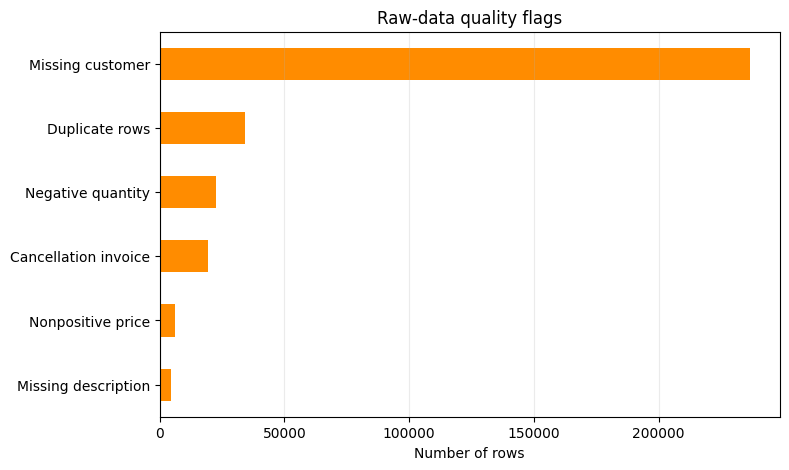

In [8]:
quality = pd.Series({
    "Missing customer": eda["CustID"].isna().sum(),
    "Missing description": eda["Description"].isna().sum(),
    "Cancellation invoice": eda["IsCancellation"].sum(),
    "Negative quantity": (eda["Quantity"] < 0).sum(),
    "Nonpositive price": (eda["Price"] <= 0).sum(),
    "Duplicate rows": eda.duplicated().sum(),
}).sort_values()

quality.plot(kind="barh", color="darkorange", figsize=(8, 5), title="Raw-data quality flags")
plt.xlabel("Number of rows")
plt.grid(axis="x", alpha=0.25)
plt.show()

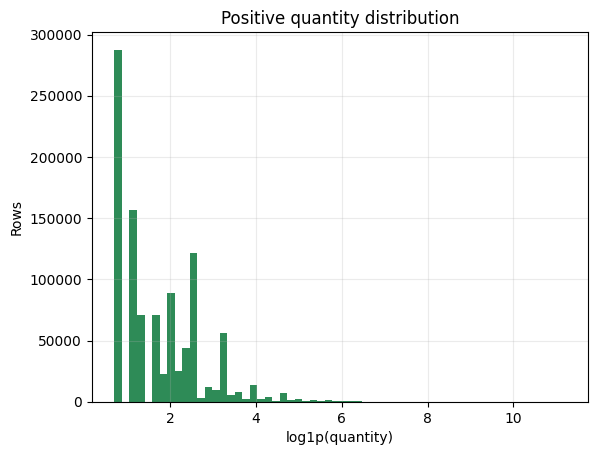

In [9]:
plt.hist(np.log1p(positive_sales["Quantity"]), bins=60, color="seagreen")
plt.title("Positive quantity distribution")
plt.xlabel("log1p(quantity)")
plt.ylabel("Rows")
plt.grid(alpha=0.25)
plt.show()

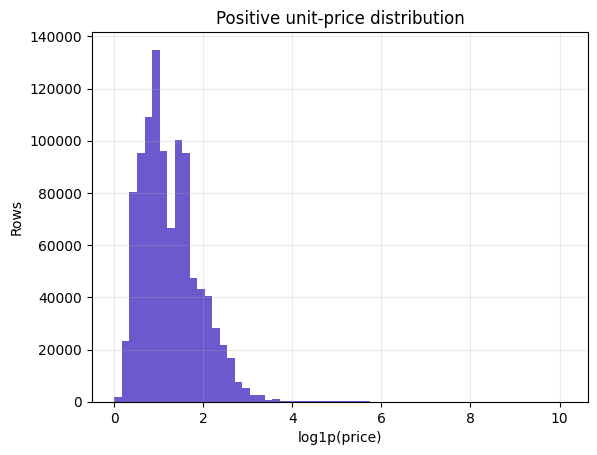

In [10]:
plt.hist(np.log1p(positive_sales["Price"]), bins=60, color="slateblue")
plt.title("Positive unit-price distribution")
plt.xlabel("log1p(price)")
plt.ylabel("Rows")
plt.grid(alpha=0.25)
plt.show()

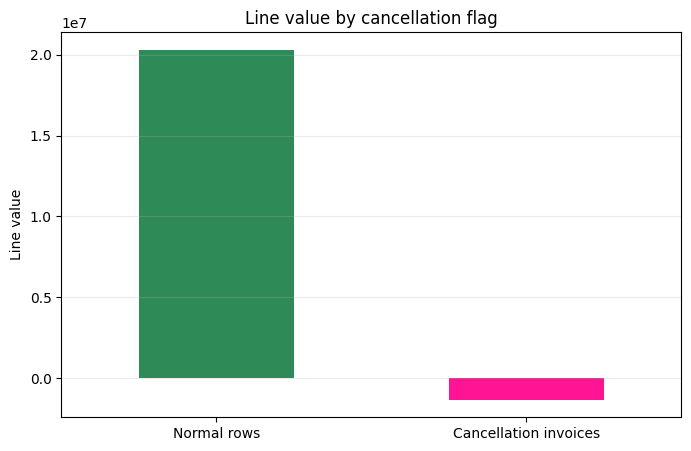

In [11]:
return_value = eda.groupby("IsCancellation")["LineValue"].sum()
return_value.index = ["Normal rows", "Cancellation invoices"]
return_value.plot(kind="bar", color=["seagreen", "deeppink"], figsize=(8, 5), title="Line value by cancellation flag")
plt.xlabel("")
plt.ylabel("Line value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

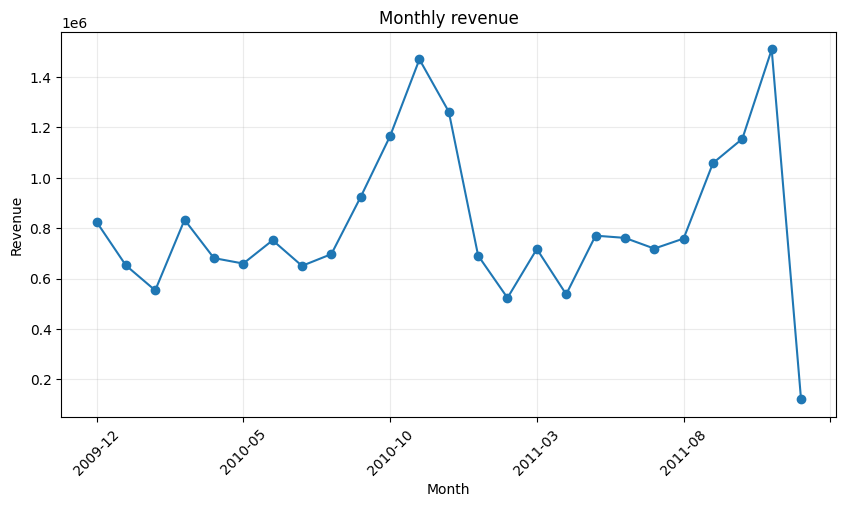

In [12]:
monthly_revenue = positive_sales.groupby("Month")["LineValue"].sum()
monthly_revenue.plot(kind="line", marker="o", figsize=(10, 5), title="Monthly revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.show()

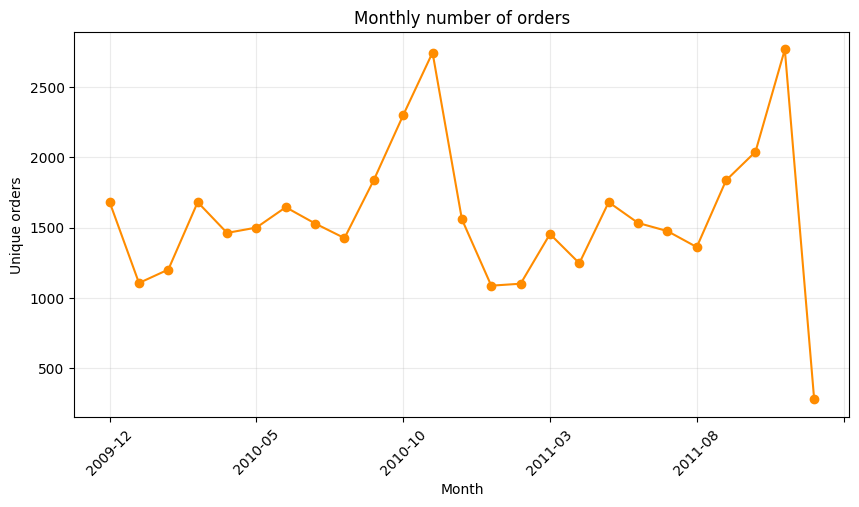

In [13]:
monthly_orders = positive_sales.groupby("Month")["Invoice"].nunique()
monthly_orders.plot(kind="line", marker="o", color="darkorange", figsize=(10, 5), title="Monthly number of orders")
plt.xlabel("Month")
plt.ylabel("Unique orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.show()

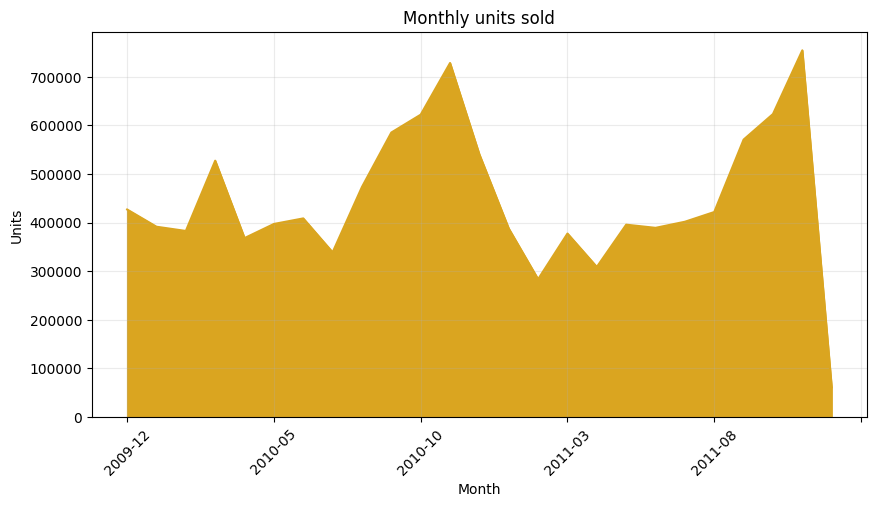

In [14]:
monthly_units = positive_sales.groupby("Month")["Quantity"].sum()
monthly_units.plot(kind="area", color="goldenrod", figsize=(10, 5), title="Monthly units sold")
plt.xlabel("Month")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.show()

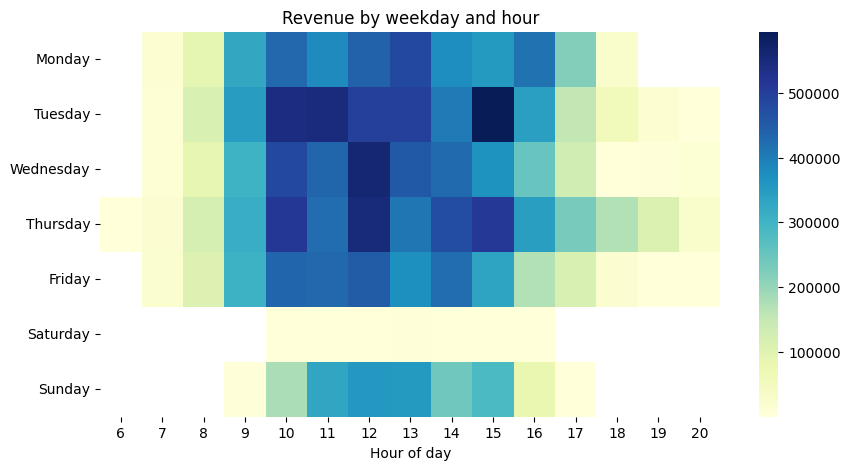

In [15]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_weekday = positive_sales.pivot_table(
    index="Weekday",
    columns="Hour",
    values="LineValue",
    aggfunc="sum",
).reindex(weekday_order)

plt.figure(figsize=(10, 5))
sb.heatmap(hour_weekday, cmap="YlGnBu")
plt.title("Revenue by weekday and hour")
plt.xlabel("Hour of day")
plt.ylabel("")
plt.show()

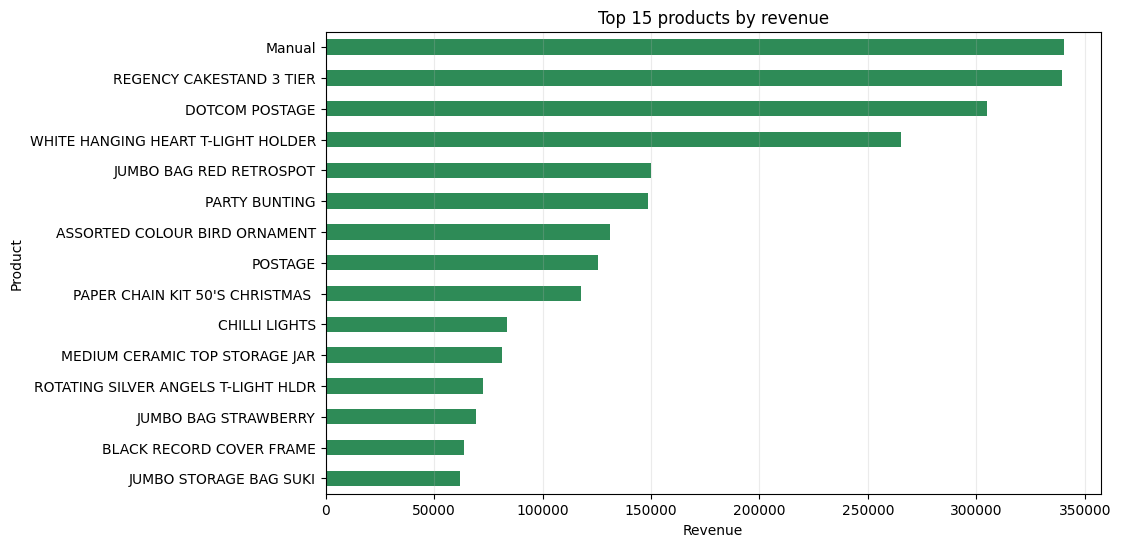

,Revenue,Units,Orders
Description,,,
Manual,340303.87,9245,782
REGENCY CAKESTAND 3 TIER,339301.55,27181,3876
DOTCOM POSTAGE,304989.94,1423,1402
WHITE HANGING HEART T-LIGHT HOLDER,265164.66,96068,5414
JUMBO BAG RED RETROSPOT,149909.27,78816,3230
PARTY BUNTING,148600.11,28296,2655
ASSORTED COLOUR BIRD ORNAMENT,131016.46,81111,2777
POSTAGE,125471.13,5365,1812
PAPER CHAIN KIT 50'S CHRISTMAS,117918.75,35072,1942


In [16]:
product_summary = positive_sales.groupby("Description").agg(
    Revenue=("LineValue", "sum"),
    Units=("Quantity", "sum"),
    Orders=("Invoice", "nunique"),
 ).sort_values("Revenue", ascending=False)

top_products = product_summary.head(15).sort_values("Revenue")
top_products["Revenue"].plot(kind="barh", figsize=(10, 6), color="seagreen", title="Top 15 products by revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.25)
plt.show()

display(product_summary.head(10))

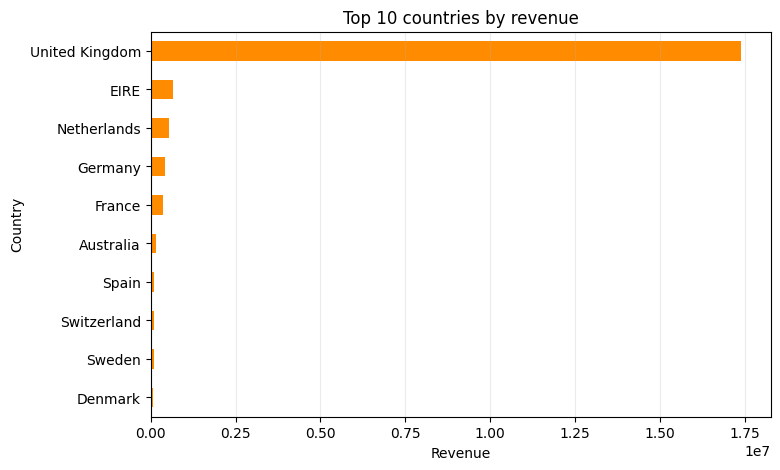

In [4]:
# Ensure the filtered sales table exists even if this cell runs before the EDA cell
if "positive_sales" not in globals():
    if "eda" in globals():
        positive_sales = eda[
            (~eda["IsCancellation"])
            & (eda["Quantity"] > 0)
            & (eda["Price"] > 0)
        ].copy()
    else:
        sales_df = sales.copy()
        sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"], errors="coerce")
        customer_col = "CustID" if "CustID" in sales_df.columns else "Customer ID"
        sales_df = sales_df.rename(columns={customer_col: "CustID"})
        sales_df["InvoiceText"] = sales_df["Invoice"].astype("string")
        sales_df["IsCancellation"] = sales_df["InvoiceText"].str.startswith("C", na=False)
        sales_df["LineValue"] = sales_df["Quantity"] * sales_df["Price"]

        positive_sales = sales_df[
            (~sales_df["IsCancellation"])
            & (sales_df["Quantity"] > 0)
            & (sales_df["Price"] > 0)
        ].copy()

customer_col = "CustID" if "CustID" in positive_sales.columns else "Customer ID"
country_summary = positive_sales.groupby("Country").agg(
    Revenue=("LineValue", "sum"),
    Orders=("Invoice", "nunique"),
    Customers=(customer_col, "nunique"),
).sort_values("Revenue", ascending=False)

top_countries = country_summary.head(10).sort_values("Revenue")
top_countries["Revenue"].plot(kind="barh", figsize=(8, 5), color="darkorange", title="Top 10 countries by revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.25)
plt.show()

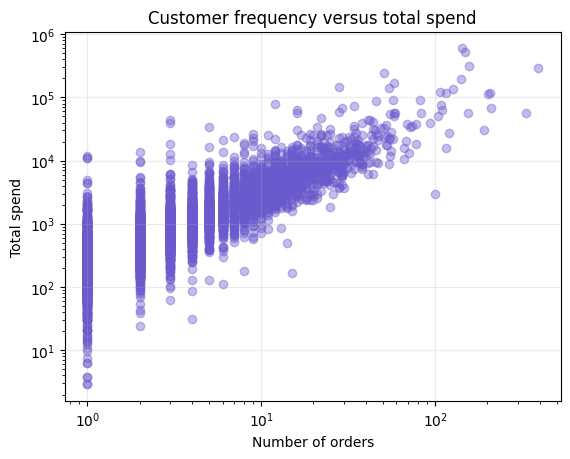

,Customer ID,LastPurchase,Frequency,Monetary,Units,Recency,AvgOrderValue
0,12346.0,2011-01-18 10:01:00,12,77556.46,74285,321,6463.038333
1,12347.0,2011-10-31 12:25:00,7,5408.50,3094,35,772.642857
2,12348.0,2011-09-25 13:13:00,5,2019.40,2714,71,403.880000
3,12349.0,2011-11-21 09:51:00,4,4428.69,1624,14,1107.172500
4,12350.0,2011-02-02 16:01:00,1,334.40,197,305,334.400000


In [ ]:
customer_sales = positive_sales.dropna(subset=["Customer ID"]).groupby("Customer ID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineValue", "sum"),
    Units=("Quantity", "sum"),
 ).reset_index()
as_of_date = positive_sales["InvoiceDate"].max() + pd.Timedelta(days=1)
customer_sales["Recency"] = (as_of_date - customer_sales["LastPurchase"]).dt.days
customer_sales["AvgOrderValue"] = customer_sales["Monetary"] / customer_sales["Frequency"]

plt.scatter(customer_sales["Frequency"], customer_sales["Monetary"], alpha=0.4, color="slateblue")
plt.title("Customer frequency versus total spend")
plt.xlabel("Number of orders")
plt.ylabel("Total spend")
plt.xscale("log")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.show()

display(customer_sales.head())

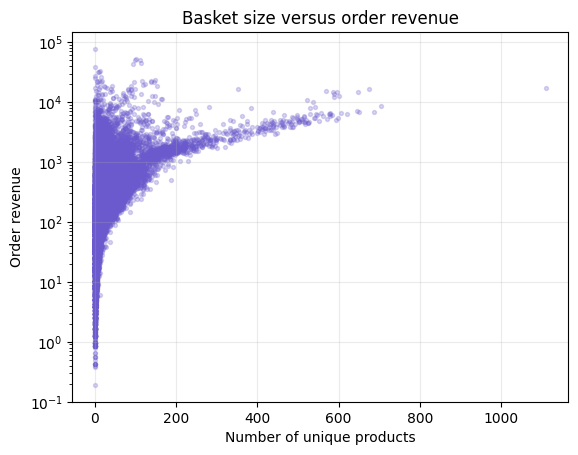

In [ ]:
basket_sizes = positive_sales.groupby("Invoice").agg(
    Products=("StockCode", "nunique"),
    Revenue=("LineValue", "sum"),
 )

plt.scatter(basket_sizes["Products"], basket_sizes["Revenue"], alpha=0.25, s=8, color="slateblue")
plt.title("Basket size versus order revenue")
plt.xlabel("Number of unique products")
plt.ylabel("Order revenue")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.show()